In [1]:
!pwd

/home/govlept1004/jupyter_home


In [2]:
!mkdir testP_datasets
!mkdir -p testP_datasets/ images
!mkdir -p testP_datasets/ lebels

!mkdir -p testP_datasets/ images/ train
!mkdir -p testP_datasets/ images/ val

!mkdir -p testP_datasets/ lebels/ train
!mkdir -p testP_datasets/ lebels/ val

mkdir: cannot create directory ‘testP_datasets/’: File exists
mkdir: cannot create directory ‘testP_datasets/’: File exists
mkdir: cannot create directory ‘testP_datasets/’: File exists
mkdir: cannot create directory ‘images/’: File exists
mkdir: cannot create directory ‘testP_datasets/’: File exists
mkdir: cannot create directory ‘images/’: File exists
mkdir: cannot create directory ‘testP_datasets/’: File exists
mkdir: cannot create directory ‘lebels/’: File exists
mkdir: cannot create directory ‘train’: File exists
mkdir: cannot create directory ‘testP_datasets/’: File exists
mkdir: cannot create directory ‘lebels/’: File exists
mkdir: cannot create directory ‘val’: File exists


In [3]:
import os
import shutil
import random

# 원본 경로
src_dir = "/mnt/c/Users/user/Desktop/yolo_txt"

# 대상 경로
base_dst = "/home/govlept1004/jupyter_home/testP_datasets/labels"
train_dir = os.path.join(base_dst, "train")
val_dir = os.path.join(base_dst, "val")

# 폴더 없으면 생성
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# 파일 목록 불러오기
all_files = [f for f in os.listdir(src_dir) if os.path.isfile(os.path.join(src_dir, f))]
random.shuffle(all_files)

# 분할 비율 (80% train, 20% val)
split_idx = int(len(all_files) * 0.8)
train_files = all_files[:split_idx]
val_files = all_files[split_idx:]

# 복사 함수
def copy_files(file_list, destination):
    for fname in file_list:
        shutil.copy(os.path.join(src_dir, fname), os.path.join(destination, fname))

# 복사 실행
copy_files(train_files, train_dir)
copy_files(val_files, val_dir)

print(f"✅ 복사 완료: {len(train_files)}개 train / {len(val_files)}개 val")


✅ 복사 완료: 106개 train / 27개 val


In [6]:
import os
import shutil

# 원본 이미지가 있는 폴더
original_dir = "/mnt/c/Users/user/Desktop/image"

# labels 경로
label_base = "/home/govlept1004/jupyter_home/testP_datasets/labels"

# image 저장 경로
image_base = "/home/govlept1004/jupyter_home/testP_datasets/images"
train_image_dir = os.path.join(image_base, "train")
val_image_dir = os.path.join(image_base, "val")

# 대상 폴더 생성
os.makedirs(train_image_dir, exist_ok=True)
os.makedirs(val_image_dir, exist_ok=True)

# 복사 함수
def copy_matching_images(label_dir, image_dir):
    for label_file in os.listdir(label_dir):
        if label_file.endswith(".txt"):
            # 이미지 파일 이름 유추 (.jpg or .png 중 실제 있는 것)
            base_name = os.path.splitext(label_file)[0]
            for ext in [".png"]:
                image_path = os.path.join(original_dir, base_name + ext)
                if os.path.exists(image_path):
                    shutil.copy(image_path, os.path.join(image_dir, os.path.basename(image_path)))
                    break  # 해당 이미지 찾았으면 멈춤

# 실행
copy_matching_images(os.path.join(label_base, "train"), train_image_dir)
copy_matching_images(os.path.join(label_base, "val"), val_image_dir)

print("✅ 이미지 복사 완료")
print("Train 이미지 수:", len(os.listdir(train_image_dir)))
print("Val 이미지 수:", len(os.listdir(val_image_dir)))


✅ 이미지 복사 완료
Train 이미지 수: 106
Val 이미지 수: 27


In [1]:
from ultralytics import YOLO

# 재학습
model = YOLO('yolov8n.pt')

# 재학습
result = model.train(
    data='/home/govlept1004/jupyter_home/testP_datasets/data.yaml',
    epochs=500,
    imgsz=640,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    batch=16,
    device=0,
    workers=4,
    name='/home/govlept1004/jupyter_home/testP_datasets/runs/'
)

New https://pypi.org/project/ultralytics/8.3.141 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.133 🚀 Python-3.10.16 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/govlept1004/jupyter_home/testP_datasets/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=500, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=runs

train: Scanning /home/govlept1004/jupyter_home/testP_datasets/labels/train.cache... 106 images, 0 backgrounds, 0


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 405.7±102.5 MB/s, size: 493.4 KB)


val: Scanning /home/govlept1004/jupyter_home/testP_datasets/labels/val.cache... 27 images, 0 backgrounds, 0 corr


Plotting labels to /home/govlept1004/jupyter_home/testP_datasets/runs2/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.00125, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to /home/govlept1004/jupyter_home/testP_datasets/runs2
Starting training for 500 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

    500/500      2.44G     0.4035     0.2928     0.8009         75        640: 100%|██████████| 7/7 [00:01<00:00
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [

                   all         27        153      0.903      0.876      0.909      0.618



500 epochs completed in 0.236 hours.
Optimizer stripped from /home/govlept1004/jupyter_home/testP_datasets/runs2/weights/last.pt, 6.3MB
Optimizer stripped from /home/govlept1004/jupyter_home/testP_datasets/runs2/weights/best.pt, 6.3MB

Validating /home/govlept1004/jupyter_home/testP_datasets/runs2/weights/best.pt...
Ultralytics 8.3.133 🚀 Python-3.10.16 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [


                   all         27        153      0.904      0.866      0.914      0.645
                   Car         19         34      0.933      0.817      0.904      0.643
                  Rock         20         39      0.963      0.821      0.891      0.704
                  Wall         14         40      0.872       0.95      0.955      0.711
                  Tank         23         40       0.85      0.875      0.905      0.521
Speed: 0.1ms preprocess, 1.3ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /home/govlept1004/jupyter_home/testP_datasets/runs2


In [3]:
# 재학습된 모델 불러오기
model = YOLO('/home/govlept1004/jupyter_home/testP_datasets/runs2/weights/best.pt')

results = model('/home/govlept1004/jupyter_home/testP_datasets/test', save=True)


image 1/5 /home/govlept1004/jupyter_home/testP_datasets/test/capture_0031.png: 384x640 1 Car, 1 Rock, 49.5ms
image 2/5 /home/govlept1004/jupyter_home/testP_datasets/test/capture_0032.png: 384x640 1 Car, 11.0ms
image 3/5 /home/govlept1004/jupyter_home/testP_datasets/test/capture_0033.png: 384x640 1 Car, 14.4ms
image 4/5 /home/govlept1004/jupyter_home/testP_datasets/test/capture_0035.png: 384x640 2 Cars, 2 Rocks, 1 Tank, 7.6ms
image 5/5 /home/govlept1004/jupyter_home/testP_datasets/test/capture_0037.png: 384x640 1 Car, 2 Rocks, 1 Tank, 13.2ms
Speed: 2.6ms preprocess, 19.1ms inference, 5.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to runs/detect/predict


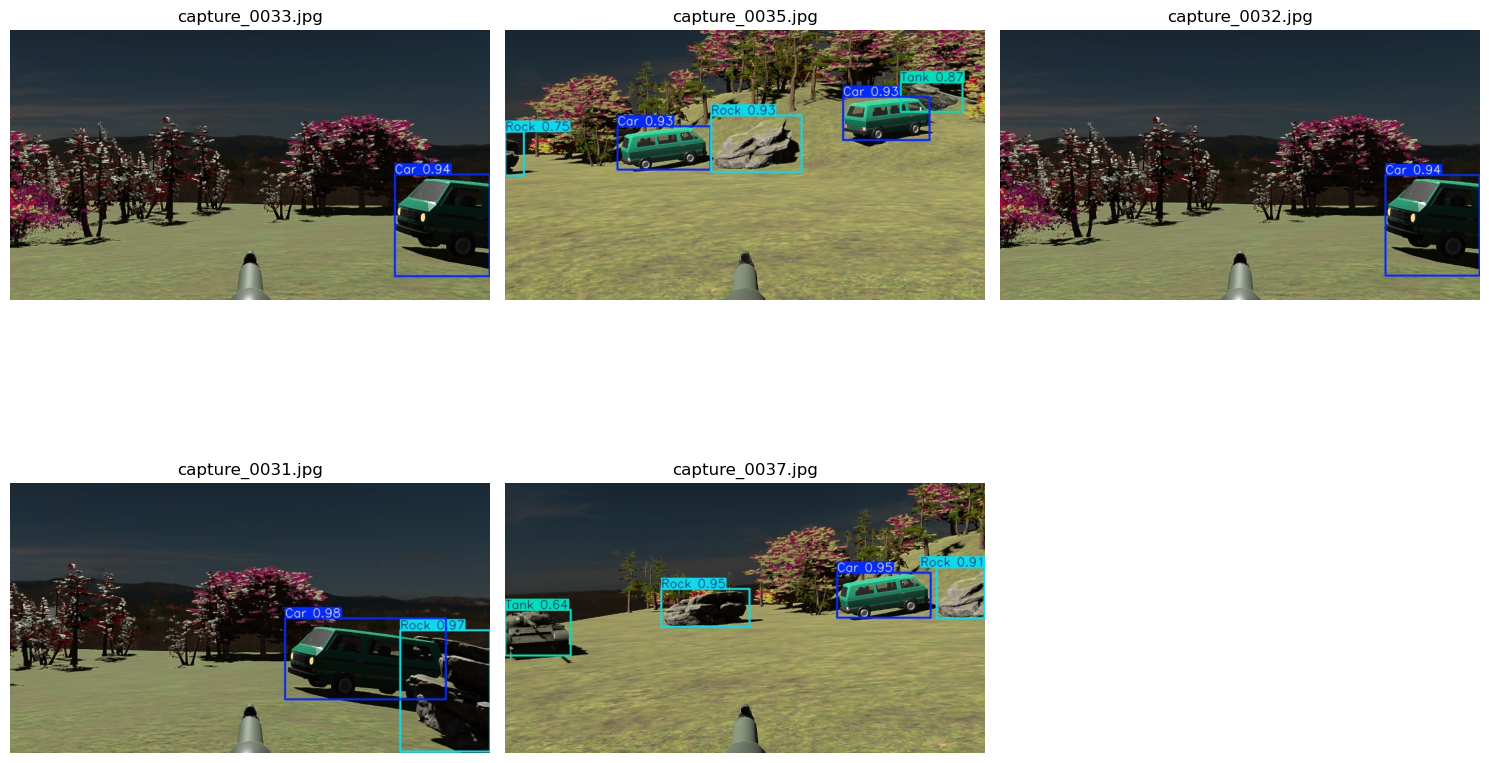

In [8]:
import os
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

# 예측 이미지가 저장된 폴더
img_dir = '/home/govlept1004/jupyter_home/testP_datasets/runs2/predict' 

# 이미지 파일 리스트
img_files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg'))]

# 여러 이미지 출력
plt.figure(figsize=(15, 10))

for i, file in enumerate(img_files[:]):
    img = cv2.imread(os.path.join(img_dir, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(file)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# 재학습된 모델 불러오기
model = YOLO('/home/govlept1004/jupyter_home/testP_datasets/runs/detect/yolov8_testP3/weights/best.pt')

results = model('/home/govlept1004/jupyter_home/testP_datasets/test', save=True)


image 1/5 /home/govlept1004/jupyter_home/testP_datasets/test/capture_0031.png: 384x640 1 Car, 1 Rock, 17.4ms
image 2/5 /home/govlept1004/jupyter_home/testP_datasets/test/capture_0032.png: 384x640 1 Car, 9.5ms
image 3/5 /home/govlept1004/jupyter_home/testP_datasets/test/capture_0033.png: 384x640 1 Car, 6.8ms
image 4/5 /home/govlept1004/jupyter_home/testP_datasets/test/capture_0035.png: 384x640 2 Cars, 2 Rocks, 1 Tank, 14.9ms
image 5/5 /home/govlept1004/jupyter_home/testP_datasets/test/capture_0037.png: 384x640 1 Car, 3 Rocks, 2 Tanks, 7.9ms
Speed: 1.7ms preprocess, 11.3ms inference, 3.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to runs/detect/predict


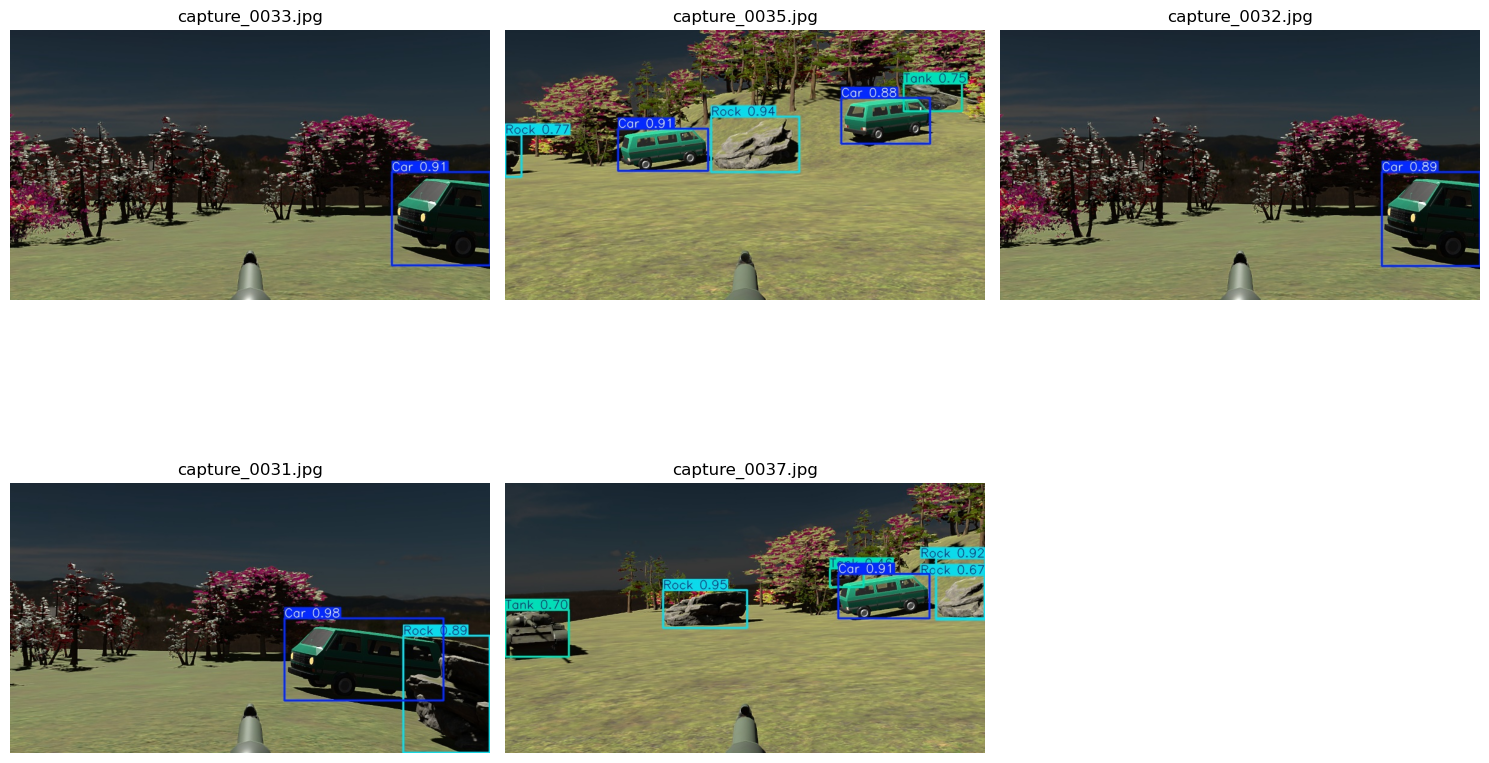

In [7]:
import os
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

# 예측 이미지가 저장된 폴더
img_dir = '/home/govlept1004/jupyter_home/testP_datasets/runs/detect/predict'  # 예: runs/detect/predict2

# 이미지 파일 리스트
img_files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg'))]

# 여러 이미지 출력
plt.figure(figsize=(15, 10))

for i, file in enumerate(img_files[:]):
    img = cv2.imread(os.path.join(img_dir, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(file)
    plt.axis('off')

plt.tight_layout()
plt.show()